# Injection Molding Defect Prediction - Modeling

In the EDA notebook I explored the data and found the parameters do separate good from scrap parts. Now I build models that actually predict good vs scrap from the 13 process parameters.

My plan, in order:

1. Prepare the data: split into train and test, and scale it.
2. Check whether the two classes can be split by a simple straight line (linear separability). This decides whether I need advanced models at all.
3. Build a Logistic Regression baseline (the simple model), then stronger models: a Support Vector Machine with a curved boundary, and XGBoost.
4. Explain the best model with SHAP, so I can point to the exact setting that caused a part to be scrap.
5. Add anomaly detection (Isolation Forest) to catch unusual cycles even without a label.

The point of step 2 is the logic of the whole notebook: if a straight line is not enough to separate good from scrap, that is the reason I move to the more advanced models, rather than using them just because they sound impressive.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Load and prepare the data

I load the raw file, rename the columns to the plain names from the EDA notebook, and rebuild the good vs scrap label. Scrap is the waste grade (quality 1), good is everything that passed (quality 2, 3, 4).

In [2]:
df = pd.read_csv('../data/raw/injection_molding.csv', sep=';')
rename = {
    'Melt temperature': 'melt_temp',
    'Mold temperature': 'mold_temp',
    'time_to_fill': 'fill_time',
    'ZDx - Plasticizing time': 'plasticizing_time',
    'ZUx - Cycle time': 'cycle_time',
    'SKx - Closing force': 'closing_force',
    'SKs - Clamping force peak value': 'clamping_force',
    'Ms - Torque peak value current cycle': 'torque_peak',
    'Mm - Torque mean value current cycle': 'torque_mean',
    'APSs - Specific back pressure peak value': 'back_pressure',
    'APVs - Specific injection pressure peak value': 'injection_pressure',
    'CPn - Screw position at the end of hold pressure': 'screw_position',
    'SVo - Shot volume': 'shot_volume',
}
df = df.rename(columns=rename)
features = list(rename.values())

df['quality'] = df['quality'].astype(int)
df['is_scrap'] = (df['quality'] == 1).astype(int)

X = df[features]
y = df['is_scrap']
print('X shape:', X.shape)
print('Scrap rate:', round(y.mean() * 100, 1), '%')

X shape: (1451, 13)
Scrap rate: 25.5 %


## 2. Train/test split and scaling

I split the data 80/20 into a training set (used to fit the models) and a test set (kept aside to judge them honestly on data they never saw). I use `stratify=y` so the scrap rate is the same in both halves.

Then I scale the features with StandardScaler. Scaling puts every parameter on the same footing (mean 0, similar spread) so that the big-number columns like the forces do not drown out the small ones. I fit the scaler on the training data only, then apply it to both, so no information from the test set leaks into training.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train:', X_train.shape[0], 'cycles')
print('Test: ', X_test.shape[0], 'cycles')
print('Train scrap rate:', round(y_train.mean() * 100, 1), '%')
print('Test scrap rate: ', round(y_test.mean() * 100, 1), '%')

Train: 1160 cycles
Test:  291 cycles
Train scrap rate: 25.5 %
Test scrap rate:  25.4 %


## 3. Are good and scrap linearly separable?

Before picking a model I ask a basic question: can I split good from scrap with a single straight line? If yes, a simple linear model is enough and there is no reason to reach for anything fancier. If no, that is the justification for the advanced models.

I check it two ways.

**First, by eye.** The data has 13 columns, and I cannot draw a 13 dimensional chart. So I use PCA, which squashes the 13 columns down to just 2 summary columns that keep as much of the spread as possible. That lets me draw every cycle as one dot on a 2D chart, colored by good or scrap. If the two colors sit in clean separate regions that a straight line could divide, the classes are close to linearly separable.

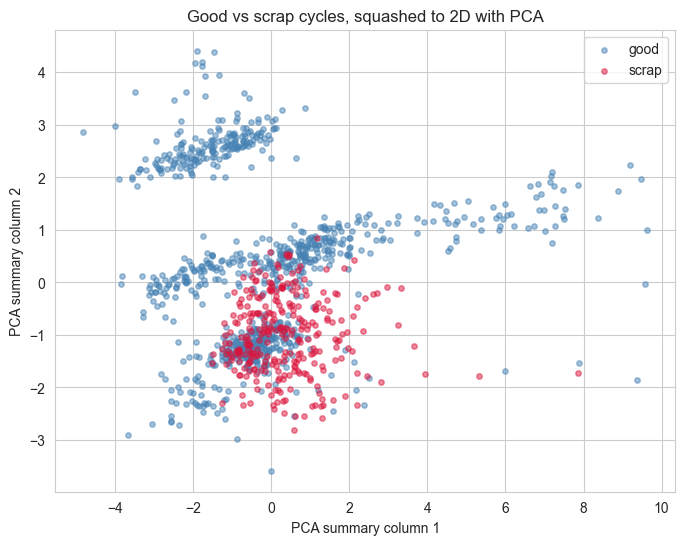

Spread kept by the 2 summary columns: 49.7 %


In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
for label, name, color in [(0, 'good', 'steelblue'), (1, 'scrap', 'crimson')]:
    mask = y_train.values == label
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                s=15, alpha=0.5, label=name, color=color)
plt.xlabel('PCA summary column 1')
plt.ylabel('PCA summary column 2')
plt.title('Good vs scrap cycles, squashed to 2D with PCA')
plt.legend()
plt.show()

print('Spread kept by the 2 summary columns:',
      round(pca.explained_variance_ratio_.sum() * 100, 1), '%')

**Second, by model.** Eyeballing a 2D squash can be misleading, so I confirm it with two models on the full 13 columns:

- a Support Vector Machine with a **straight line** boundary (`kernel='linear'`)
- a Support Vector Machine with a **curved** boundary (`kernel='rbf'`)

If the straight line model already does almost as well as the curved one, the classes are basically linearly separable. If the curved model clearly beats the straight line, they are not, and that is the reason to use models that can draw curved boundaries.

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score

lin = SVC(kernel='linear', random_state=RANDOM_STATE)
lin.fit(X_train_scaled, y_train)
lin_pred = lin.predict(X_test_scaled)

rbf = SVC(kernel='rbf', random_state=RANDOM_STATE)
rbf.fit(X_train_scaled, y_train)
rbf_pred = rbf.predict(X_test_scaled)

print('Straight line SVM : accuracy', round(accuracy_score(y_test, lin_pred), 3),
      '| scrap F1', round(f1_score(y_test, lin_pred), 3))
print('Curved SVM        : accuracy', round(accuracy_score(y_test, rbf_pred), 3),
      '| scrap F1', round(f1_score(y_test, rbf_pred), 3))

Straight line SVM : accuracy 0.863 | scrap F1 0.697
Curved SVM        : accuracy 0.914 | scrap F1 0.823


Both checks agree: the classes are **not** cleanly separable by a straight line.

In the PCA picture the good and scrap dots sit in overlapping clouds rather than two clean blocks, so no single straight line would split them. The models confirm it. The straight line SVM gets a scrap F1 of about 0.70, while the curved SVM jumps to about 0.82 (and accuracy from 0.86 to 0.91). That big gap means a curved boundary captures something a straight line cannot.

This is the justification for the rest of the notebook: because a simple linear boundary is not enough, it makes sense to use models that can draw curved, flexible boundaries, namely the curved SVM and XGBoost. I am not using them because they sound advanced, I am using them because the data needs them.

(One note on the PCA picture: the 2 summary columns keep only about 50% of the spread of the original 13 columns, so the chart is a rough flattened view. The model based check on the full 13 columns is the more reliable test, and it agrees.)